<a href="https://www.kaggle.com/code/lalit7881/250k-salary-prediction-dataset?scriptVersionId=304098021" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/rhythmghai/250k-job-salary-prediction-dataset/job_salary_prediction_dataset.csv


## Loading dataset

In [2]:
path = "/kaggle/input/datasets/rhythmghai/250k-job-salary-prediction-dataset/job_salary_prediction_dataset.csv"

df = pd.read_csv(path)

In [3]:
df.head()        # first 5 rows
df.tail()        # last 5 rows
df.sample(5)     # random rows

,job_title,experience_years,education_level,skills_count,industry,company_size,location,remote_work,certifications,salary
237548,Business Analyst,2,Diploma,12,Media,Startup,Australia,No,4,76750
48777,AI Engineer,20,Bachelor,15,Technology,Medium,India,Yes,1,135317
127674,AI Engineer,18,Bachelor,2,Finance,Large,Netherlands,Yes,0,180806
76288,Cybersecurity Analyst,10,Master,6,Consulting,Enterprise,India,Hybrid,1,113000
141299,AI Engineer,7,Bachelor,13,Education,Startup,Netherlands,Yes,0,142536


In [4]:
df.shape

(250000, 10)

In [5]:
df.columns

Index(['job_title', 'experience_years', 'education_level', 'skills_count',
       'industry', 'company_size', 'location', 'remote_work', 'certifications',
       'salary'],
      dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 10 columns):
 #   Column            Non-Null Count   Dtype 
---  ------            --------------   ----- 
 0   job_title         250000 non-null  object
 1   experience_years  250000 non-null  int64 
 2   education_level   250000 non-null  object
 3   skills_count      250000 non-null  int64 
 4   industry          250000 non-null  object
 5   company_size      250000 non-null  object
 6   location          250000 non-null  object
 7   remote_work       250000 non-null  object
 8   certifications    250000 non-null  int64 
 9   salary            250000 non-null  int64 
dtypes: int64(4), object(6)
memory usage: 19.1+ MB


In [7]:
df.describe()

,experience_years,skills_count,certifications,salary
count,250000.000000,250000.000000,250000.000000,250000.000000
mean,10.005408,9.997812,2.491928,145718.080524
std,6.060602,5.479288,1.706475,37407.952729
min,0.000000,1.000000,0.000000,31867.000000
25%,5.000000,5.000000,1.000000,119358.000000
50%,10.000000,10.000000,2.000000,143453.000000
75%,15.000000,15.000000,4.000000,169492.000000
max,20.000000,19.000000,5.000000,333046.000000


In [8]:
df.isnull().sum()

job_title           0
experience_years    0
education_level     0
skills_count        0
industry            0
company_size        0
location            0
remote_work         0
certifications      0
salary              0
dtype: int64

In [9]:
df = df.dropna()
# OR
df.fillna(method="ffill", inplace=True)

In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df = df.drop_duplicates()

In [12]:
df.nunique()

job_title               12
experience_years        21
education_level          5
skills_count            19
industry                10
company_size             5
location                10
remote_work              3
certifications           6
salary              118956
dtype: int64

In [13]:
df.dtypes

job_title           object
experience_years     int64
education_level     object
skills_count         int64
industry            object
company_size        object
location            object
remote_work         object
certifications       int64
salary               int64
dtype: object

## EDA

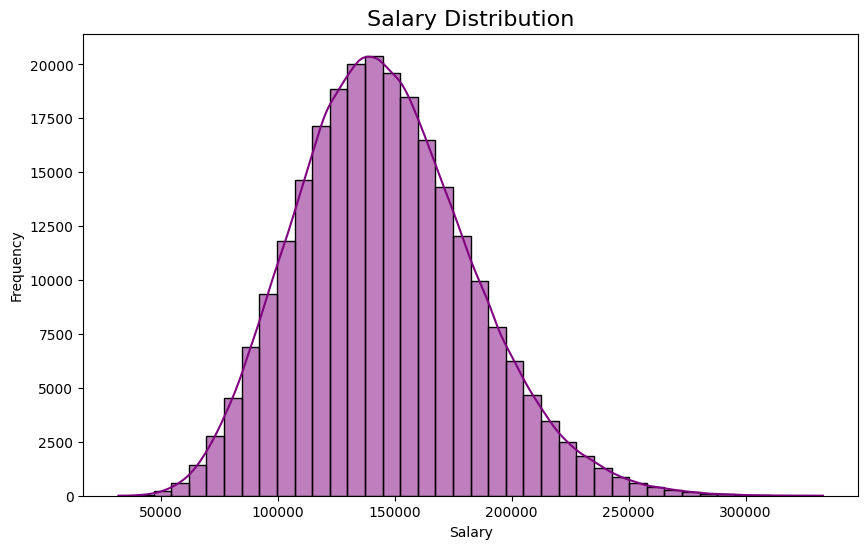

In [14]:
plt.figure(figsize=(10,6))

sns.histplot(df['salary'], bins=40, kde=True, color='purple')

plt.title("Salary Distribution", fontsize=16)
plt.xlabel("Salary")
plt.ylabel("Frequency")

plt.show()

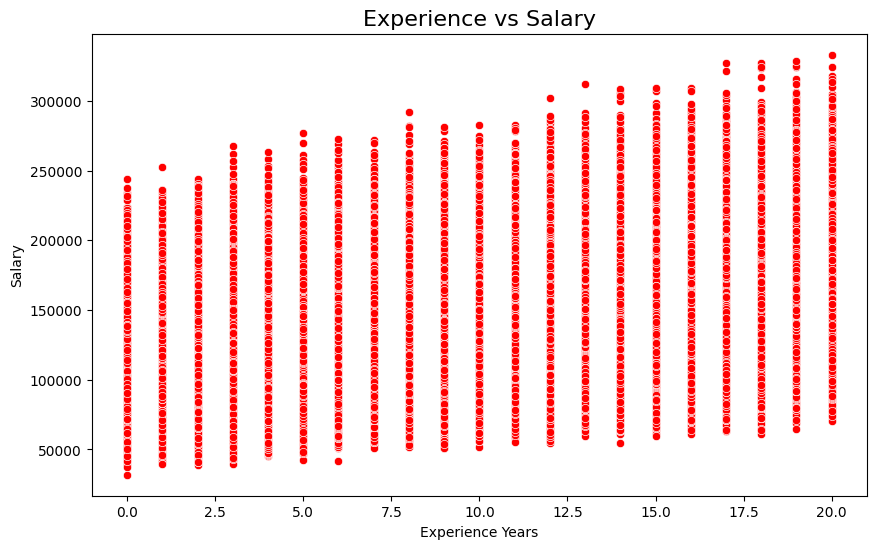

In [15]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    x=df['experience_years'],
    y=df['salary'],
    color='red'
)

plt.title("Experience vs Salary", fontsize=16)
plt.xlabel("Experience Years")
plt.ylabel("Salary")

plt.show()

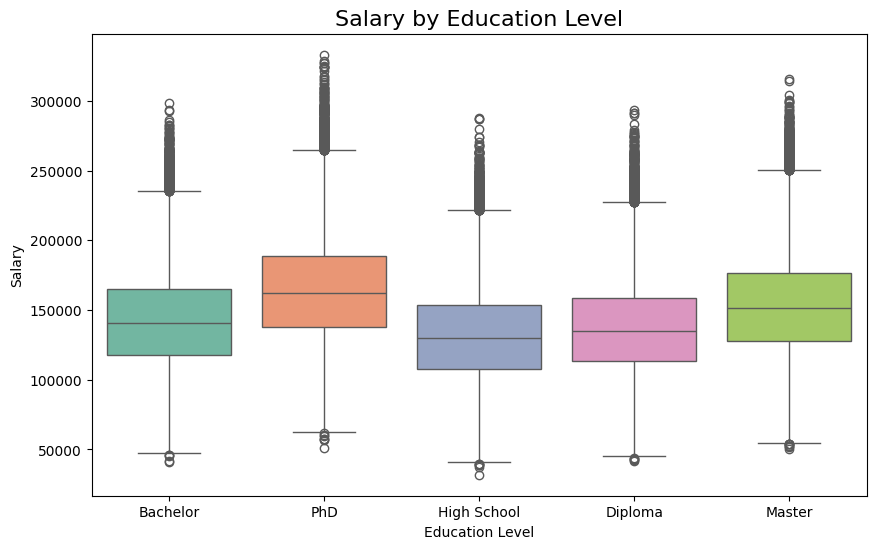

In [16]:
plt.figure(figsize=(10,6))

sns.boxplot(
    x='education_level',
    y='salary',
    data=df,
    palette='Set2'
)

plt.title("Salary by Education Level", fontsize=16)
plt.xlabel("Education Level")
plt.ylabel("Salary")

plt.show()

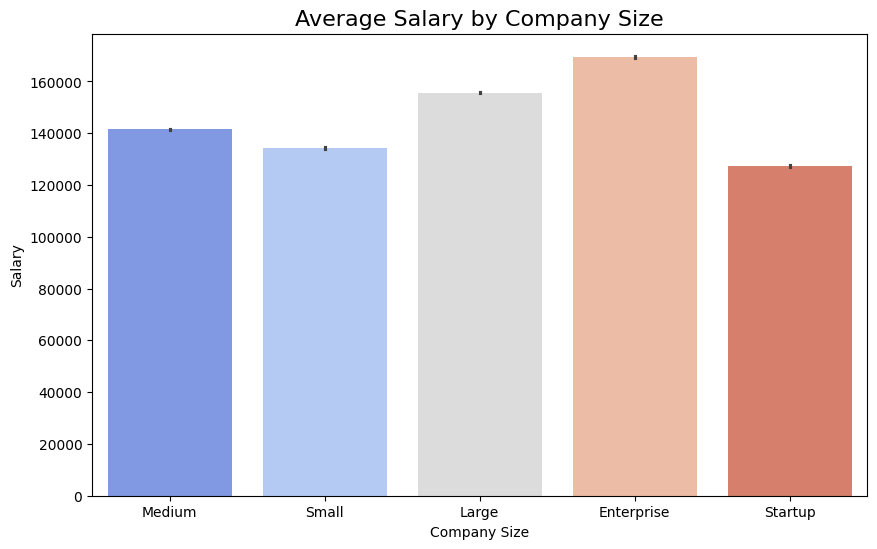

In [17]:
plt.figure(figsize=(10,6))

sns.barplot(
    x='company_size',
    y='salary',
    data=df,
    palette='coolwarm'
)

plt.title("Average Salary by Company Size", fontsize=16)
plt.xlabel("Company Size")
plt.ylabel("Salary")

plt.show()

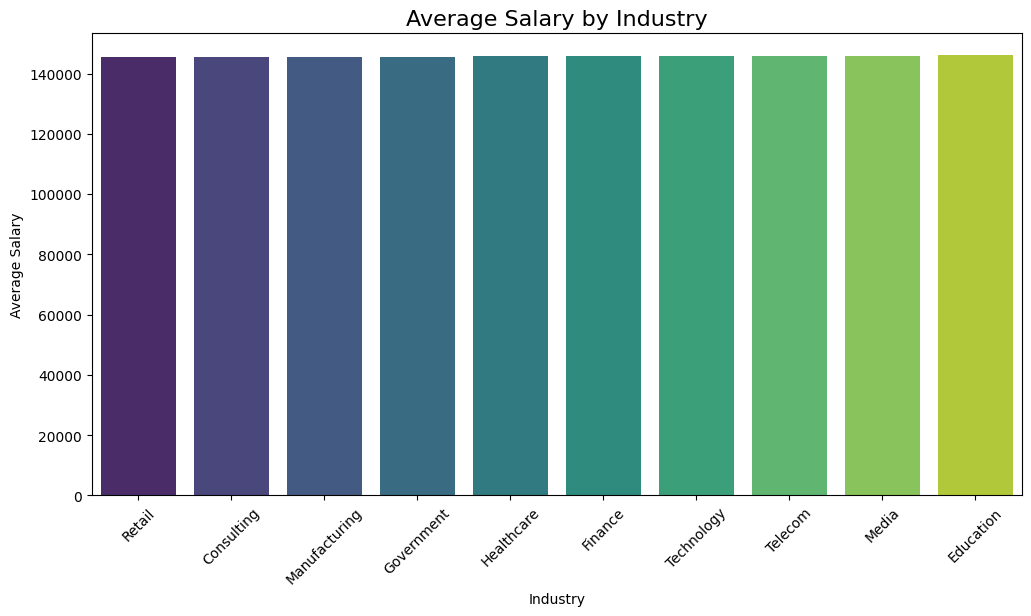

In [18]:
plt.figure(figsize=(12,6))

industry_salary = df.groupby("industry")["salary"].mean().sort_values()

sns.barplot(
    x=industry_salary.index,
    y=industry_salary.values,
    palette='viridis'
)

plt.title("Average Salary by Industry", fontsize=16)
plt.xlabel("Industry")
plt.ylabel("Average Salary")
plt.xticks(rotation=45)

plt.show()

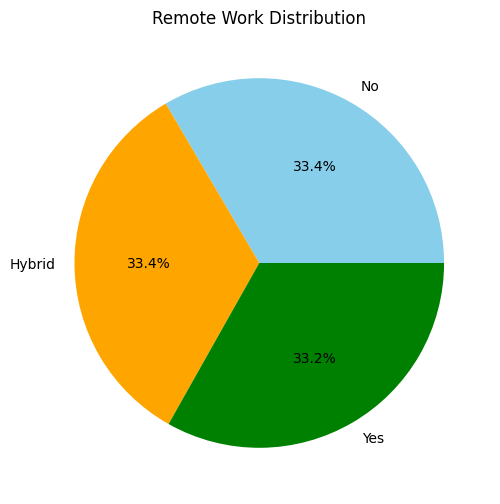

In [19]:
plt.figure(figsize=(6,6))

df['remote_work'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    colors=['skyblue','orange','green']
)

plt.title("Remote Work Distribution")
plt.ylabel("")

plt.show()

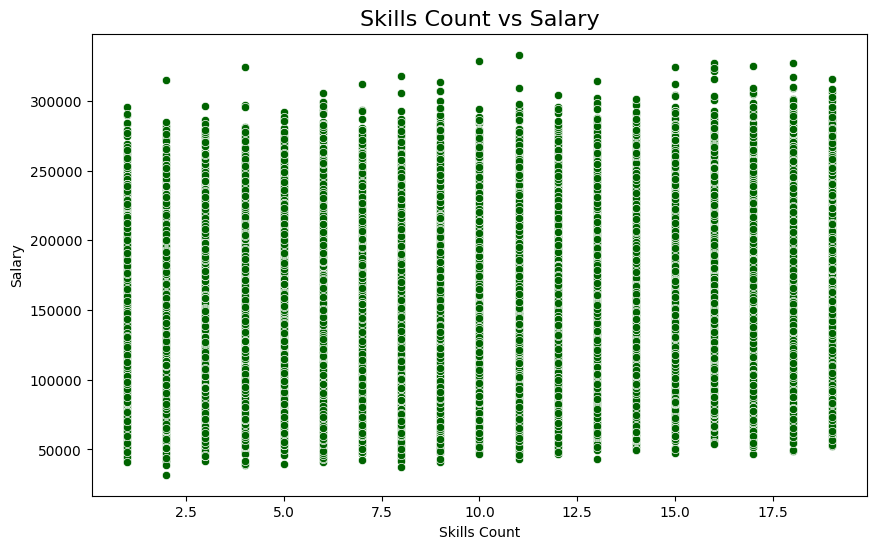

In [20]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    x='skills_count',
    y='salary',
    data=df,
    color='darkgreen'
)

plt.title("Skills Count vs Salary", fontsize=16)
plt.xlabel("Skills Count")
plt.ylabel("Salary")

plt.show()

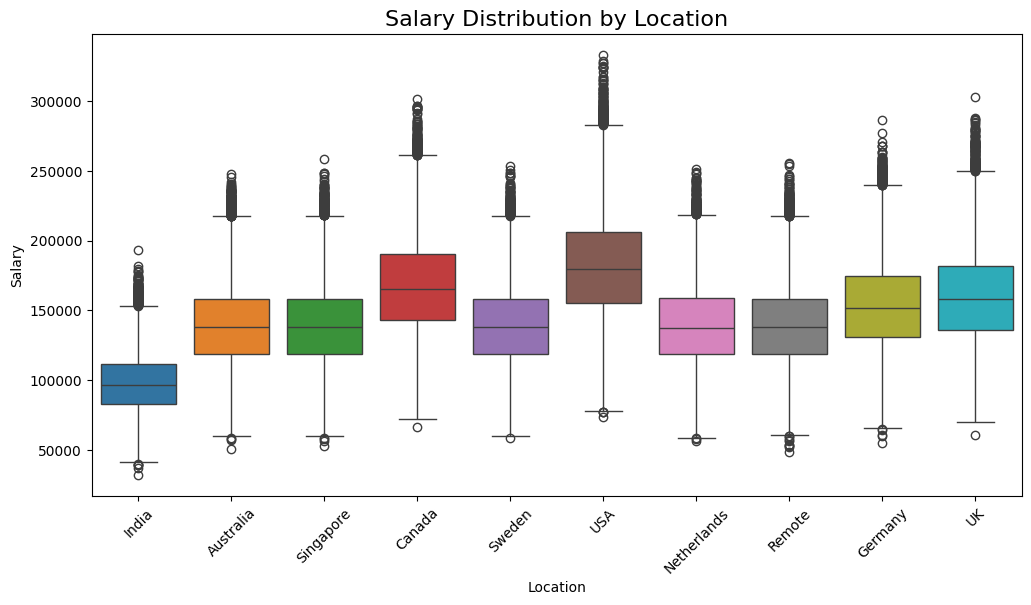

In [21]:
plt.figure(figsize=(12,6))

sns.boxplot(
    x='location',
    y='salary',
    data=df,
    palette='tab10'
)

plt.title("Salary Distribution by Location", fontsize=16)
plt.xlabel("Location")
plt.ylabel("Salary")
plt.xticks(rotation=45)

plt.show()

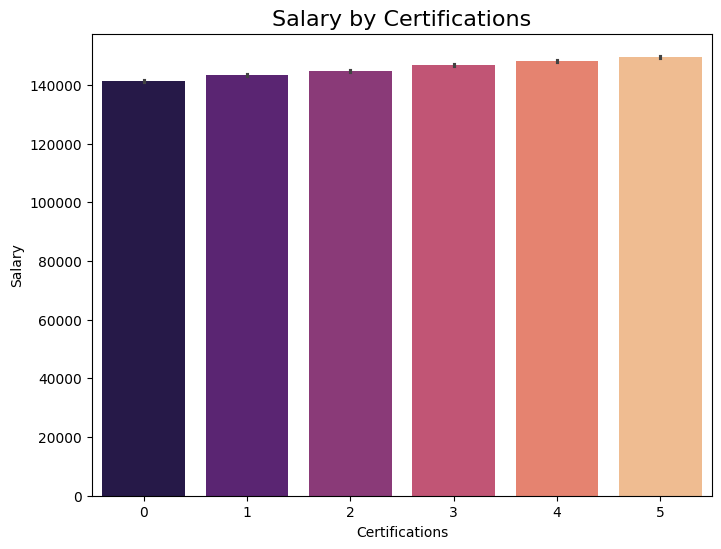

In [22]:
plt.figure(figsize=(8,6))

sns.barplot(
    x='certifications',
    y='salary',
    data=df,
    palette='magma'
)

plt.title("Salary by Certifications", fontsize=16)
plt.xlabel("Certifications")
plt.ylabel("Salary")

plt.show()

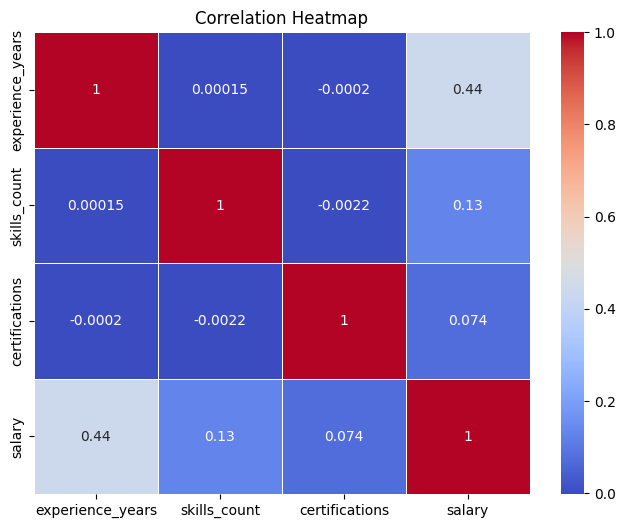

In [23]:
plt.figure(figsize=(8,6))

numeric_df = df.select_dtypes(include=['int64','float64'])

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap='coolwarm',
    linewidths=0.5
)

plt.title("Correlation Heatmap")

plt.show()

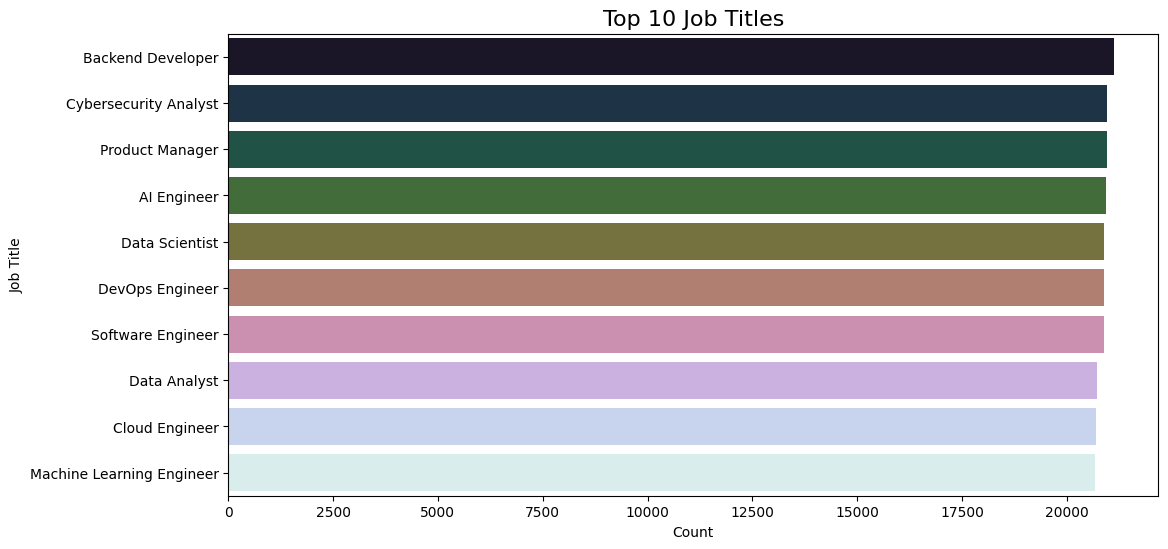

In [24]:
plt.figure(figsize=(12,6))

top_jobs = df['job_title'].value_counts().head(10)

sns.barplot(
    x=top_jobs.values,
    y=top_jobs.index,
    palette='cubehelix'
)

plt.title("Top 10 Job Titles", fontsize=16)
plt.xlabel("Count")
plt.ylabel("Job Title")

plt.show()

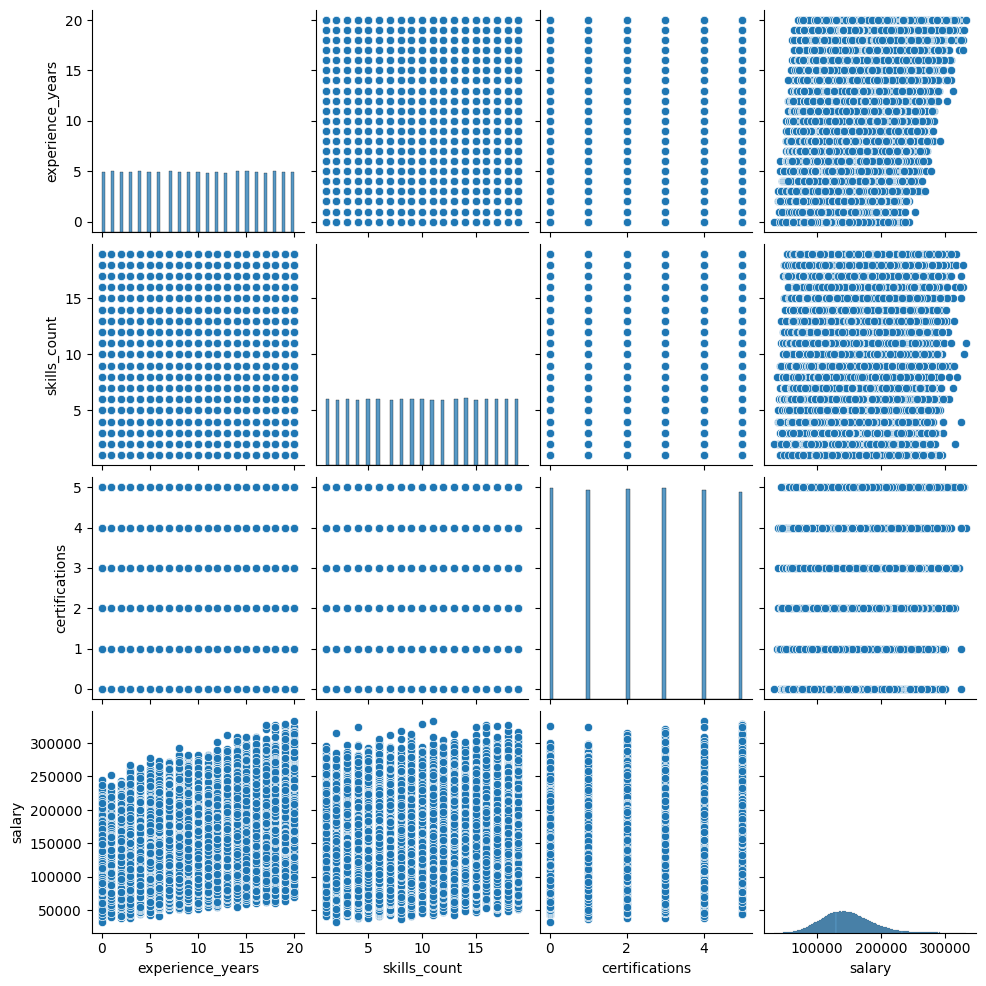

In [25]:
sns.pairplot(
    df[['experience_years','skills_count','certifications','salary']],
    palette='husl'
)

plt.show()

## Feature engineering

In [26]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

from sklearn.metrics import accuracy_score, classification_report, roc_curve, auc

In [27]:
median_salary = df['salary'].median()

df['salary_class'] = (df['salary'] > median_salary).astype(int)

df.drop('salary', axis=1, inplace=True)

In [28]:
categorical_cols = df.select_dtypes(include='object').columns

le = LabelEncoder()

for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

In [29]:
X = df.drop('salary_class', axis=1)
y = df['salary_class']

In [30]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [31]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [32]:
models = {
    "Logistic Regression": LogisticRegression(),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "Gradient Boosting": GradientBoostingClassifier()
}

In [33]:
results = {}

for name, model in models.items():
    
    model.fit(X_train_scaled, y_train)
    
    y_pred = model.predict(X_test_scaled)
    
    acc = accuracy_score(y_test, y_pred)
    
    results[name] = acc
    
    print("Model:", name)
    print("Accuracy:", acc)
    print(classification_report(y_test, y_pred))
    print("="*50)

Model: Logistic Regression
Accuracy: 0.74718
              precision    recall  f1-score   support

           0       0.75      0.75      0.75     25001
           1       0.75      0.75      0.75     24999

    accuracy                           0.75     50000
   macro avg       0.75      0.75      0.75     50000
weighted avg       0.75      0.75      0.75     50000

Model: Decision Tree
Accuracy: 0.91352
              precision    recall  f1-score   support

           0       0.91      0.92      0.91     25001
           1       0.92      0.91      0.91     24999

    accuracy                           0.91     50000
   macro avg       0.91      0.91      0.91     50000
weighted avg       0.91      0.91      0.91     50000

Model: Random Forest
Accuracy: 0.9345
              precision    recall  f1-score   support

           0       0.93      0.94      0.93     25001
           1       0.93      0.93      0.93     24999

    accuracy                           0.93     50000
   mac

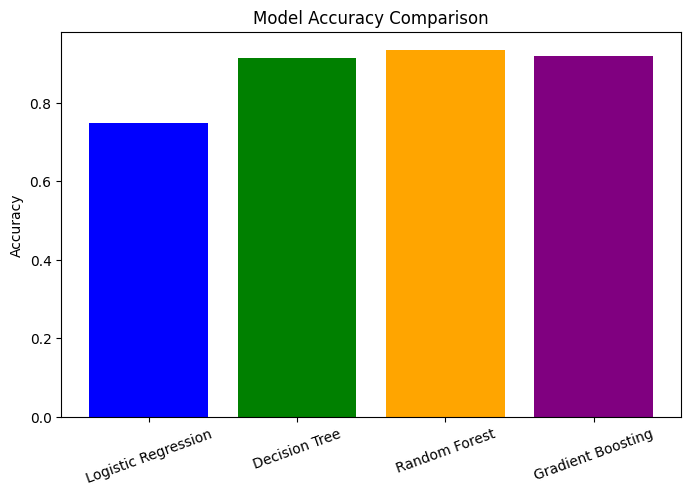

In [34]:
plt.figure(figsize=(8,5))

plt.bar(results.keys(), results.values(), color=['blue','green','orange','purple'])

plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.xticks(rotation=20)

plt.show()

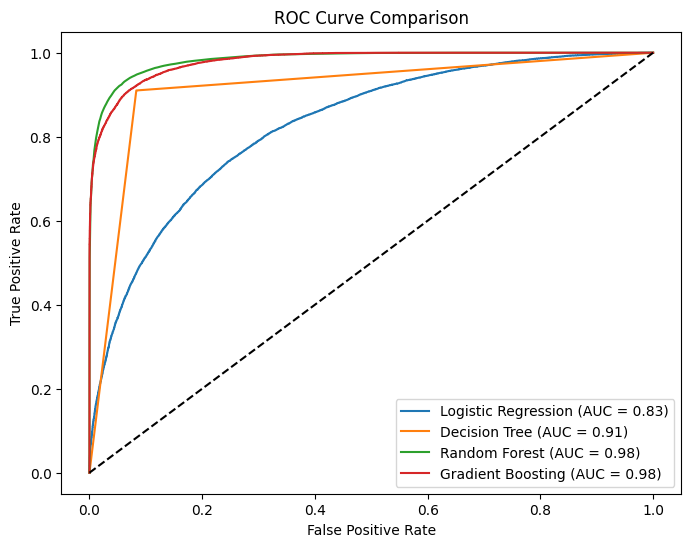

In [35]:
plt.figure(figsize=(8,6))

for name, model in models.items():
    
    y_prob = model.predict_proba(X_test_scaled)[:,1]
    
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    
    roc_auc = auc(fpr, tpr)
    
    plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.2f})")

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve Comparison")

plt.legend()

plt.show()

In [36]:
results_df = pd.DataFrame({
    "Model": results.keys(),
    "Accuracy": results.values()
})

results_df.sort_values(by="Accuracy", ascending=False)

,Model,Accuracy
2,Random Forest,0.93450
3,Gradient Boosting,0.91928
1,Decision Tree,0.91352
0,Logistic Regression,0.74718


## Thank you...pls upvote!!!!!!!